# Audit 2 — What do prediction benchmarks on Parse measure?

**Setting (State / Rhaister, donor split):** all cell types of Donor1, Donor4, Donor9 and Donor12 are query contexts; for them, 28 cytokines are observed (panel) and 62 must be predicted (test). The main metric is `pearson_delta`: Pearson correlation between observed and predicted expression deltas (cytokine minus **PBS**), averaged over query context x test cytokine. The **half-sample reference** (half A predicts half B of the same cells) is used as an approximate ceiling; Rhaister reports approaching it.

**Concerns from Aim 1:**
1. Every delta against PBS contains the same non-specific shift (PBS wells are in the edge row). A predictor that knows only this shift, and nothing about cytokines, may score high.
2. Both halves of the half-sample reference come from the **same well**, so the ceiling includes well noise as if it were signal.

**Predictors compared (for query donor d, cell type ct, test cytokine c):**
- `half-sample`: half A of the observed delta (the paper's ceiling)
- `additive`: training-donor mean for c + the query context's panel offset (the strong simple baseline of the paper)
- `context mean`: the mean of the query context's panel deltas, the same vector for every cytokine (no cytokine information)
- `inert shift`: mean delta of the 13 biologically inert cytokines in the training donors (no cytokine and no donor information)

Everything is repeated with the **inert-cytokine reference**. Deltas are pseudobulk log-normalized differences (the paper uses means of per-cell log values), on well-expressed genes.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

CACHE_DIR = "data/parse10m/cache"
RESULTS_DIR = "results/aim1_benchmark_audit"
os.makedirs(RESULTS_DIR, exist_ok=True)

CONTROL = "PBS"
INERT = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO", "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
QUERY_DONORS = ["Donor1", "Donor4", "Donor9", "Donor12"]          # State donor split (parse_tomls/donor.toml)
TEST = ['C5a', 'TWEAK', 'LIF', 'IL-17C', 'FGF-beta', 'BAFF', 'FLT3L', 'IFN-lambda2', '4-1BBL', 'IL-17E', 'IL-2',
        'IL-19', 'PRL', 'IL-16', 'IL-7', 'GM-CSF', 'IL-17A', 'IL-13', 'IL-36-alpha', 'PSPN', 'EPO', 'IL-9', 'IL-31',
        'IL-11', 'LT-alpha1-beta2', 'TL1A', 'IL-32-beta', 'IFN-omega', 'IL-8', 'Noggin', 'IFN-epsilon', 'IL-17F',
        'Leptin', 'IL-33', 'IL-35', 'OSM', 'IL-34', 'HGF', 'IL-1Ra', 'LIGHT', 'CD27L', 'SCF', 'IL-1-alpha',
        'TGF-beta1', 'CD30L', 'IL-24', 'IFN-gamma', 'IFN-alpha1', 'IFN-lambda1', 'GITRL', 'VEGF', 'ADSF', 'IL-15',
        'EGF', 'IL-3', 'IL-17B', 'IL-6', 'IL-4', 'IL-10', 'CT-1', 'IFN-lambda3', 'TRAIL']
VAL = ['G-CSF', 'IFN-beta', 'M-CSF', 'IGF-1']
MIN_CELLS_HALF = 20
N_GENES = 2000
TARGET = 1e4

sums = np.load(os.path.join(CACHE_DIR, "pb_sums.npy"))
meta = pd.read_pickle(os.path.join(CACHE_DIR, "pb_meta.pkl")).reset_index(drop=True)
genes = np.load(os.path.join(CACHE_DIR, "pb_genes.npy"), allow_pickle=True).astype(str)
LOOK = {(r.donor, r.cell_type, r.cytokine, int(r.half)): (i, r.n_cells) for i, r in meta.iterrows()}
CYTOS = sorted(c for c in meta.cytokine.unique() if c != CONTROL)
TEST = [c for c in TEST if c in CYTOS]
PANEL = [c for c in CYTOS if c not in TEST]                    # observed for query donors (includes VAL)
DONORS = sorted(meta.donor.unique()); TRAIN = [d for d in DONORS if d not in QUERY_DONORS]
CELL_TYPES = sorted(meta.cell_type.unique())
print(f"{len(TEST)} test, {len(PANEL)} panel cytokines; train donors: {TRAIN}")

61 test, 29 panel cytokines; train donors: ['Donor10', 'Donor11', 'Donor2', 'Donor3', 'Donor5', 'Donor6', 'Donor7', 'Donor8']


## 1. Deltas per half and full, under both references

In [2]:
def lognorm(x): return np.log1p(x / max(x.sum(), 1) * TARGET)
def half(d, ct, c, h):
    v = LOOK.get((d, ct, c, h))
    return None if v is None or v[1] < MIN_CELLS_HALF else sums[v[0]].astype(np.float64)

# gene set: well expressed in PBS across cell types
pbs_all = np.zeros(sums.shape[1])
for (d, ct, c, h), (i, n) in LOOK.items():
    if c == CONTROL: pbs_all += sums[i]
GIDX = np.argsort(lognorm(pbs_all))[::-1][:N_GENES]

def prof(d, ct, c, h):
    x = half(d, ct, c, h)
    return None if x is None else lognorm(x)[GIDX]

DELTA = {"PBS": {}, "inert": {}}          # key (d, ct, c) -> (delta_A, delta_B, delta_full)
for d in DONORS:
    for ct in CELL_TYPES:
        pb = [prof(d, ct, CONTROL, h) for h in (0, 1)]
        inert_h = {k: [prof(d, ct, k, h) for h in (0, 1)] for k in INERT}
        for c in CYTOS:
            x = [prof(d, ct, c, h) for h in (0, 1)]
            if any(v is None for v in x): continue
            if all(v is not None for v in pb):
                DELTA["PBS"][(d, ct, c)] = (x[0] - pb[0], x[1] - pb[1], (x[0] + x[1]) / 2 - (pb[0] + pb[1]) / 2)
            refs = [inert_h[k] for k in INERT if k != c and all(v is not None for v in inert_h[k])]
            if len(refs) >= 3:
                r = [np.mean([v[h] for v in refs], 0) for h in (0, 1)]
                DELTA["inert"][(d, ct, c)] = (x[0] - r[0], x[1] - r[1], (x[0] + x[1]) / 2 - (r[0] + r[1]) / 2)
print({k: len(v) for k, v in DELTA.items()})

{'PBS': 10791, 'inert': 10701}


## 2. Predictors and pearson_delta

In [3]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

rows = []
for ref, D in DELTA.items():
    for ct in CELL_TYPES:
        train_mean = {c: np.mean([D[(e, ct, c)][2] for e in TRAIN if (e, ct, c) in D], 0)
                      for c in CYTOS if sum((e, ct, c) in D for e in TRAIN) >= 3}
        inert_shift = [train_mean[k] for k in INERT if k in train_mean]
        if len(inert_shift) < 3: continue
        inert_shift = np.mean(inert_shift, 0)
        for d in QUERY_DONORS:
            panel_obs = {p: D[(d, ct, p)][2] for p in PANEL if (d, ct, p) in D and p in train_mean}
            if len(panel_obs) < 5: continue
            ctx_mean = np.mean(list(panel_obs.values()), 0)
            offset = ctx_mean - np.mean([train_mean[p] for p in panel_obs], 0)
            for c in TEST:
                if (d, ct, c) not in D or c not in train_mean: continue
                A, B, full = D[(d, ct, c)]
                preds = {"half-sample": (A, B), "additive": (train_mean[c] + offset, full),
                         "context mean": (ctx_mean, full), "inert shift": (inert_shift, full)}
                for name, (p, obs) in preds.items():
                    rows.append(dict(reference=ref, predictor=name, cell_type=ct, donor=d, cytokine=c,
                                     inert=c in INERT, pearson_delta=pearson(p, obs)))
RES = pd.DataFrame(rows)
RES.to_csv(f"{RESULTS_DIR}/pearson_delta_per_context.csv", index=False)

order = ["half-sample", "additive", "context mean", "inert shift"]
BENCH = (RES.groupby(["reference", "predictor"]).pearson_delta.mean().unstack().reindex(columns=order).round(3))
BENCH_IMMUNE = (RES[~RES.inert].groupby(["reference", "predictor"]).pearson_delta.mean().unstack()
                .reindex(columns=order).round(3))
BENCH.to_csv(f"{RESULTS_DIR}/pearson_delta_summary.csv"); BENCH_IMMUNE.to_csv(f"{RESULTS_DIR}/pearson_delta_summary_immune.csv")
print("All test cytokines:"); display(BENCH)
print("Immune test cytokines only:"); display(BENCH_IMMUNE)

All test cytokines:


predictor,half-sample,additive,context mean,inert shift
reference,,,,
PBS,0.529,0.566,0.336,0.116
inert,0.520,0.488,0.232,-0.002


Immune test cytokines only:


predictor,half-sample,additive,context mean,inert shift
reference,,,,
PBS,0.546,0.572,0.339,0.106
inert,0.538,0.509,0.267,-0.002


## 3. How much of the ceiling is the shared well?
For inert test cytokines the true response is (near) zero, so two inert cytokines of the same donor and cell type are **replicate wells** of the same condition. Compare the half-sample reference (same well) with a cross-well replicate (another inert cytokine, same donor and cell type), under the inert reference. The gap is the part of the half-sample ceiling that comes from sharing a well.

In [4]:
D = DELTA["inert"]; rows = []
for d in QUERY_DONORS:
    for ct in CELL_TYPES:
        inert_here = [k for k in INERT if (d, ct, k) in D]
        for i, k in enumerate(inert_here):
            A, B, full = D[(d, ct, k)]
            rows.append(dict(kind="same well (half-sample)", r=pearson(A, B)))
            for k2 in inert_here[i + 1:]:
                rows.append(dict(kind="different wells (replicate)", r=pearson(D[(d, ct, k2)][0], B)))
CEIL = pd.DataFrame(rows).groupby("kind").r.agg(["mean", "count"]).round(3)
CEIL.to_csv(f"{RESULTS_DIR}/ceiling_same_vs_different_well.csv")
CEIL

,mean,count
kind,,
different wells (replicate),-0.033,2996
same well (half-sample),0.412,503


## 4. Figure

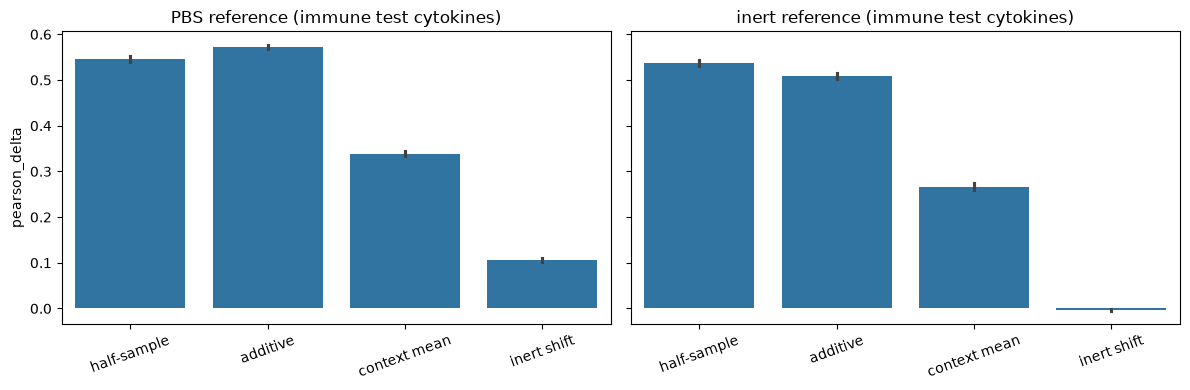

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, ref in zip(ax, ["PBS", "inert"]):
    d = RES[(RES.reference == ref) & ~RES.inert]
    sns.barplot(data=d, x="predictor", y="pearson_delta", order=order, ax=a, errorbar="se", color="tab:blue")
    a.set_title(f"{ref} reference (immune test cytokines)"); a.set_xlabel(""); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/pearson_delta_by_reference.png", dpi=150, bbox_inches="tight"); plt.show()

## How to read
- **PBS reference:** if `context mean` and `inert shift` (no cytokine information) score close to `additive` and to `half-sample`, the metric mainly rewards the shared PBS shift, and "approaching the ceiling" says little about predicting cytokine biology.
- **Inert reference:** these two predictors should drop toward zero while `additive` keeps its value if it carries real cytokine information.
- **Ceiling:** if same-well correlation clearly exceeds different-well correlation for inert cytokines, the half-sample reference is inflated by well sharing.